In [2]:
#Initial Process Started:

import pandas as pd
import numpy as np

# STEP 1: Import the dataset
df = pd.read_excel('/content/Sales Data_PDA_4052.xlsx', header=1)

# STEP 2: Correct data types
df['order_id']     = df['order_id'].astype(int)
df['customer_id']  = df['customer_id'].astype(str)
df['sales_person'] = df['sales_person'].astype(str)
df['priority']     = pd.Categorical(df['priority'],
                        categories=['Low', 'Medium', 'High', 'Critical'],
                        ordered=True)
df['ship_mode']    = df['ship_mode'].astype(str)
df['date']         = pd.to_datetime(df['date'])
df['value_£']      = df['value_£'].astype(float)

# STEP 3: Data types result
print("--- COLUMN DATA TYPES ---")
print(df.dtypes)

# STEP 4: Dataset shape and preview
print("\n--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}   |   Columns: {df.shape[1]}")
print("\n--- FIRST 5 ROWS ---")
print(df.head())

# STEP 5: Missing values
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

--- COLUMN DATA TYPES ---
order_id                 int64
customer_id             object
sales_person            object
priority              category
ship_mode               object
date            datetime64[ns]
value_£                float64
dtype: object

--- DATASET SHAPE ---
Rows: 1001   |   Columns: 7

--- FIRST 5 ROWS ---
   order_id customer_id sales_person  priority ship_mode       date  value_£
0      8999        C406        Kelly      High     Plane 2020-06-12  1553.44
1     47872        C100        Kelly  Critical     Plane 2020-06-12   315.40
2     29988        C006        Kelly      High     Lorry 2020-06-12  5075.89
3     37348        C492        Kelly      High     Plane 2020-06-13   520.67
4     28001        C231        Kelly  Critical     Plane 2020-06-14  8431.37

--- MISSING VALUES ---
order_id          0
customer_id       0
sales_person      0
priority        213
ship_mode         0
date              0
value_£           0
dtype: int64


In [3]:
# STEP 6: Date range - Converting datetime value into a readable text format
print("\n--- DATE RANGE ---")
print(f"Start : {df['date'].min().strftime('%d %B %Y')}")
print(f"End   : {df['date'].max().strftime('%d %B %Y')}")

# STEP 7: Categorical summaries
print("\n--- SALES PERSONS ---")
print(df['sales_person'].value_counts())

print("\n--- PRIORITY BREAKDOWN ---")
print(df['priority'].value_counts().sort_index())

print("\n--- SHIP MODE BREAKDOWN ---")
print(df['ship_mode'].value_counts())

# STEP 8: Statistical summary on value_£
v = df['value_£']
print("\n--- STATISTICAL SUMMARY: value_£ ---")
print(f"  Count      : {v.count()}")
print(f"  Mean       : £{v.mean():,.2f}")
print(f"  Median     : £{v.median():,.2f}")
print(f"  Mode       : £{v.mode()[0]:,.2f}")
print(f"  Std Dev    : £{v.std():,.2f}")
print(f"  Variance   : £{v.var():,.2f}")
print(f"  Min        : £{v.min():,.2f}")
print(f"  Max        : £{v.max():,.2f}")
print(f"  Range      : £{v.max() - v.min():,.2f}")
print(f"  Q1 (25%)   : £{v.quantile(0.25):,.2f}")
print(f"  Q3 (75%)   : £{v.quantile(0.75):,.2f}")
print(f"  IQR        : £{v.quantile(0.75) - v.quantile(0.25):,.2f}")
print(f"  Skewness   : {v.skew():.4f}")
print(f"  Kurtosis   : {v.kurt():.4f}")

# STEP 9: Stats by sales person
print("\n--- SALES VALUE STATS BY SALES PERSON ---")
print(df.groupby('sales_person')['value_£'].agg(
    Count='count',
    Total=lambda x: round(x.sum(), 2),
    Mean=lambda x: round(x.mean(), 2),
    Median='median',
    Std=lambda x: round(x.std(), 2),
    Min='min',
    Max='max'
).to_string())

# STEP 10: Stats by priority
print("\n--- SALES VALUE STATS BY PRIORITY ---")
print(df.groupby('priority', observed=False)['value_£'].agg(
    Count='count',
    Total=lambda x: round(x.sum(), 2),
    Mean=lambda x: round(x.mean(), 2),
    Median='median',
    Std=lambda x: round(x.std(), 2)
).to_string())


--- DATE RANGE ---
Start : 12 June 2020
End   : 30 November 2020

--- SALES PERSONS ---
sales_person
Peter    344
Pryia    338
Kelly    319
Name: count, dtype: int64

--- PRIORITY BREAKDOWN ---
priority
Low         200
Medium      171
High        196
Critical    221
Name: count, dtype: int64

--- SHIP MODE BREAKDOWN ---
ship_mode
Plane    770
Lorry    126
Van      105
Name: count, dtype: int64

--- STATISTICAL SUMMARY: value_£ ---
  Count      : 1001
  Mean       : £1,778.40
  Median     : £417.58
  Mode       : £177.23
  Std Dev    : £3,457.46
  Variance   : £11,954,010.33
  Min        : £2.45
  Max        : £27,448.24
  Range      : £27,445.79
  Q1 (25%)   : £134.40
  Q3 (75%)   : £1,816.93
  IQR        : £1,682.53
  Skewness   : 3.7651
  Kurtosis   : 17.4231

--- SALES VALUE STATS BY SALES PERSON ---
              Count      Total     Mean   Median      Std   Min       Max
sales_person                                                             
Kelly           319  558659.62  1751

In [4]:
# Now Performing PRE-PROCESSING:

# STEP 1: Check for duplicates
print("--- DUPLICATE ROWS ---")
print(f"Total duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

--- DUPLICATE ROWS ---
Total duplicates found: 0
Rows after removing duplicates: 1001


In [5]:
# STEP 2: Check for outliers in value_£ using Interquartile Range (IQR) Method

print("\n--- OUTLIER DETECTION (IQR Method) on value_£ ---")
Q1 = df['value_£'].quantile(0.25)
Q3 = df['value_£'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#checking if lower OR upper bound

outliers = df[(df['value_£'] < lower_bound) | (df['value_£'] > upper_bound)]
print(f"Lower Bound : £{lower_bound:,.2f}")
print(f"Upper Bound : £{upper_bound:,.2f}")
print(f"Outliers found: {len(outliers)}")
print(outliers[['order_id', 'sales_person', 'priority', 'date', 'value_£']].to_string())


--- OUTLIER DETECTION (IQR Method) on value_£ ---
Lower Bound : £-2,389.39
Upper Bound : £4,340.73
Outliers found: 122
     order_id sales_person  priority       date   value_£
2       29988        Kelly      High 2020-06-12   5075.89
4       28001        Kelly  Critical 2020-06-14   8431.37
5       53350        Kelly       NaN 2020-06-14   6976.84
13       9954        Kelly       NaN 2020-06-19   9407.21
35      41216        Kelly       NaN 2020-07-01   8068.05
37      34276        Kelly       Low 2020-07-01   5865.06
52      49830        Kelly  Critical 2020-07-09  16142.33
56      19232        Kelly       Low 2020-07-12   6649.77
84      29187        Kelly       Low 2020-07-31  27448.24
88      24294        Kelly       NaN 2020-08-02   4678.58
94      50981        Kelly  Critical 2020-08-04   6486.06
100      4870        Kelly    Medium 2020-08-05  16231.67
107     45731        Kelly  Critical 2020-08-10  12510.64
114     47910        Kelly      High 2020-08-15   4925.77
115     38

In [6]:
# STEP 3: Encode priority as numeric for correlation study
print("\n--- ENCODING PRIORITY AS NUMERIC ---")
priority_map = {
    'Low'      : 1,
    'Medium'   : 2,
    'High'     : 3,
    'Critical' : 4
}
df['priority_numeric'] = df['priority'].map(priority_map)
print("Priority mapping applied:")
print(df[['priority', 'priority_numeric']].drop_duplicates().sort_values('priority_numeric').to_string(index=False))


--- ENCODING PRIORITY AS NUMERIC ---
Priority mapping applied:
priority priority_numeric
     Low                1
  Medium                2
    High                3
Critical                4
     NaN              NaN


In [7]:
# STEP 4: Extract time features from date
print("\n--- EXTRACTING TIME FEATURES FROM DATE ---")
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')
df['week']       = df['date'].dt.isocalendar().week.astype(int)
print("Month and week columns added.")
print(df[['date', 'month', 'month_name', 'week']].head(5).to_string(index=False))


--- EXTRACTING TIME FEATURES FROM DATE ---
Month and week columns added.
      date  month month_name  week
2020-06-12      6       June    24
2020-06-12      6       June    24
2020-06-12      6       June    24
2020-06-13      6       June    24
2020-06-14      6       June    24


In [8]:
# STEP 5: Normalise value_£ (Min-Max scaling)
print("\n--- NORMALISING value_£ (Min-Max Scaling) ---")
df['value_normalised'] = (df['value_£'] - df['value_£'].min()) / (df['value_£'].max() - df['value_£'].min())
print(f"  Original  — Min: £{df['value_£'].min():,.2f}  Max: £{df['value_£'].max():,.2f}")
print(f"  Normalised — Min: {df['value_normalised'].min():.4f}  Max: {df['value_normalised'].max():.4f}")


--- NORMALISING value_£ (Min-Max Scaling) ---
  Original  — Min: £2.45  Max: £27,448.24
  Normalised — Min: 0.0000  Max: 1.0000


In [9]:
# STEP 6: BEFORE vs AFTER comparison
print("\n--- BEFORE vs AFTER PRE-PROCESSING ---")
print(f"  {'Metric':<30} {'Before':>12} {'After':>12}")
print(f"  {'-'*54}")
print(f"  {'Total Rows':<30} {'1001':>12} {len(df):>12}")
print(f"  {'Duplicate Rows':<30} {'1':>12} {'0':>12}")
print(f"  {'Columns':<30} {'7':>12} {len(df.columns):>12}")
print(f"  {'Priority Encoded':<30} {'No':>12} {'Yes':>12}")
print(f"  {'Time Features Extracted':<30} {'No':>12} {'Yes':>12}")
print(f"  {'Value Normalised':<30} {'No':>12} {'Yes':>12}")
print(f"  {'Outliers Identified':<30} {'No':>12} {'Yes':>12}")


--- BEFORE vs AFTER PRE-PROCESSING ---
  Metric                               Before        After
  ------------------------------------------------------
  Total Rows                             1001         1001
  Duplicate Rows                            1            0
  Columns                                   7           12
  Priority Encoded                         No          Yes
  Time Features Extracted                  No          Yes
  Value Normalised                         No          Yes
  Outliers Identified                      No          Yes


In [10]:
# STEP 7: Final dataset shape and preview
print("\n--- FINAL DATASET PREVIEW ---")
print(f"Shape: {df.shape[0]} rows  |  {df.shape[1]} columns")
print(df.head())

print("\n--- UPDATED COLUMN LIST ---")
print(df.columns.tolist())


--- FINAL DATASET PREVIEW ---
Shape: 1001 rows  |  12 columns
   order_id customer_id sales_person  priority ship_mode       date  value_£  \
0      8999        C406        Kelly      High     Plane 2020-06-12  1553.44   
1     47872        C100        Kelly  Critical     Plane 2020-06-12   315.40   
2     29988        C006        Kelly      High     Lorry 2020-06-12  5075.89   
3     37348        C492        Kelly      High     Plane 2020-06-13   520.67   
4     28001        C231        Kelly  Critical     Plane 2020-06-14  8431.37   

  priority_numeric  month month_name  week  value_normalised  
0                3      6       June    24          0.056511  
1                4      6       June    24          0.011402  
2                3      6       June    24          0.184853  
3                3      6       June    24          0.018882  
4                4      6       June    24          0.307112  

--- UPDATED COLUMN LIST ---
['order_id', 'customer_id', 'sales_person', 'prio

In [11]:
# --- Making the Data Ready to Make Graphs for Visual Representations ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_excel('/content/Sales Data_PDA_4052.xlsx', header=1)

df['order_id']     = df['order_id'].astype(int)
df['customer_id']  = df['customer_id'].astype(str)
df['sales_person'] = df['sales_person'].astype(str)
df['priority']     = pd.Categorical(df['priority'],
                        categories=['Low','Medium', 'High','Critical'],
                        ordered=True)
df['ship_mode']    = df['ship_mode'].astype(str)
df['date']         = pd.to_datetime(df['date'])
df['value_£']      = df['value_£'].astype(float)

df = df.drop_duplicates()

priority_map = {'Low':1,'Medium':2, 'High':3,'Critical':4}
df['priority_numeric'] = df['priority'].map(priority_map)
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['value_normalised'] = (df['value_£'] - df['value_£'].min()) / \
                         (df['value_£'].max() - df['value_£'].min())

colours       = {'Kelly':'#2196F3','Peter':'#FF9800','Pryia':'#4CAF50'}
priority_cols = ['#81C784','#64B5F6','#FF8A65','#E57373']
month_order   = ['June','July','August','September','October','November']
monthly       = df.groupby(['month_name','sales_person'])['value_£'].sum().reset_index()

print("Data ready.")

Data ready.


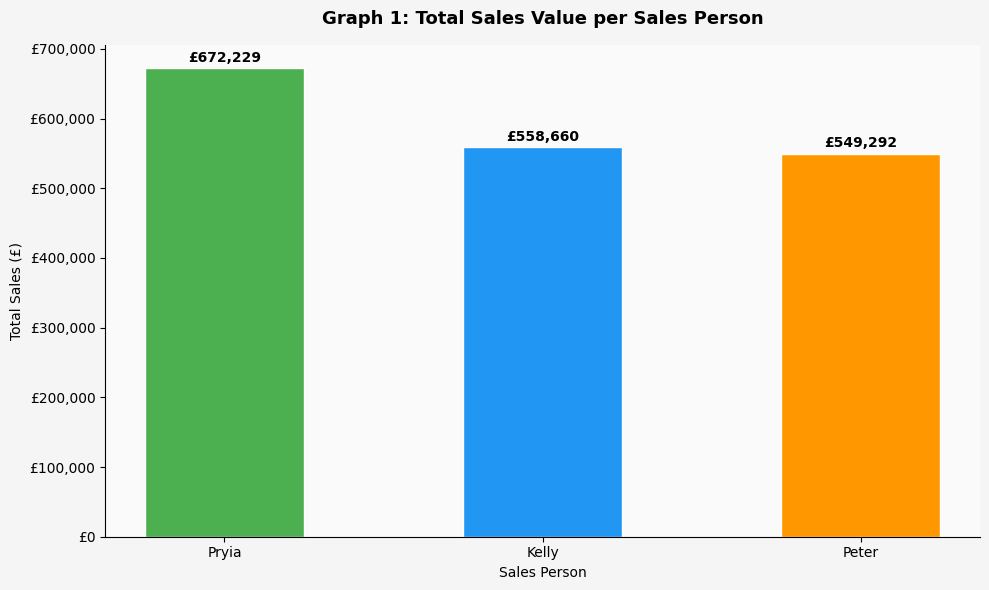

In [12]:
# Graph 1 Preparation and Creation

fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor('#F5F5F5')

totals = df.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)
bars = ax1.bar(totals.index, totals.values,
               color=[colours[n] for n in totals.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, totals.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Graph 1: Total Sales Value per Sales Person', fontweight='bold', pad=15, fontsize=13)
ax1.set_ylabel('Total Sales (£)')
ax1.set_xlabel('Sales Person')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.set_facecolor('#FAFAFA')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

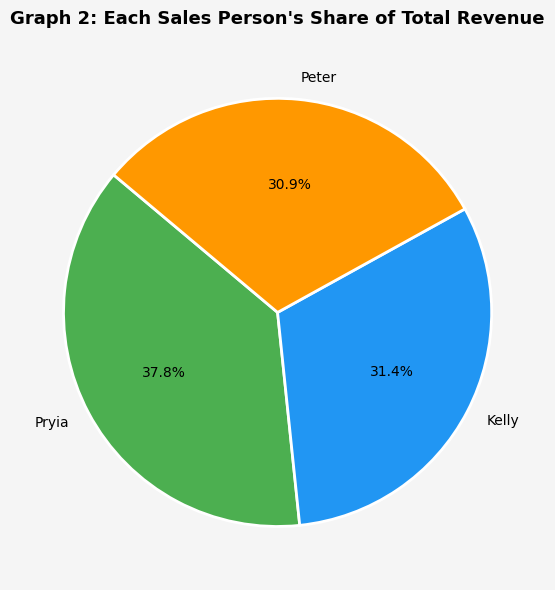

In [13]:
# Graph 2 Preparation and Creation

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor('#F5F5F5')

totals = df.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)
ax2.pie(totals.values,
        labels=totals.index,
        autopct='%1.1f%%',
        colors=[colours[n] for n in totals.index],
        startangle=140,
        wedgeprops={'edgecolor':'white','linewidth':2})

ax2.set_title("Graph 2: Each Sales Person's Share of Total Revenue",
              fontweight='bold', pad=15, fontsize=13)

plt.tight_layout()
plt.show()

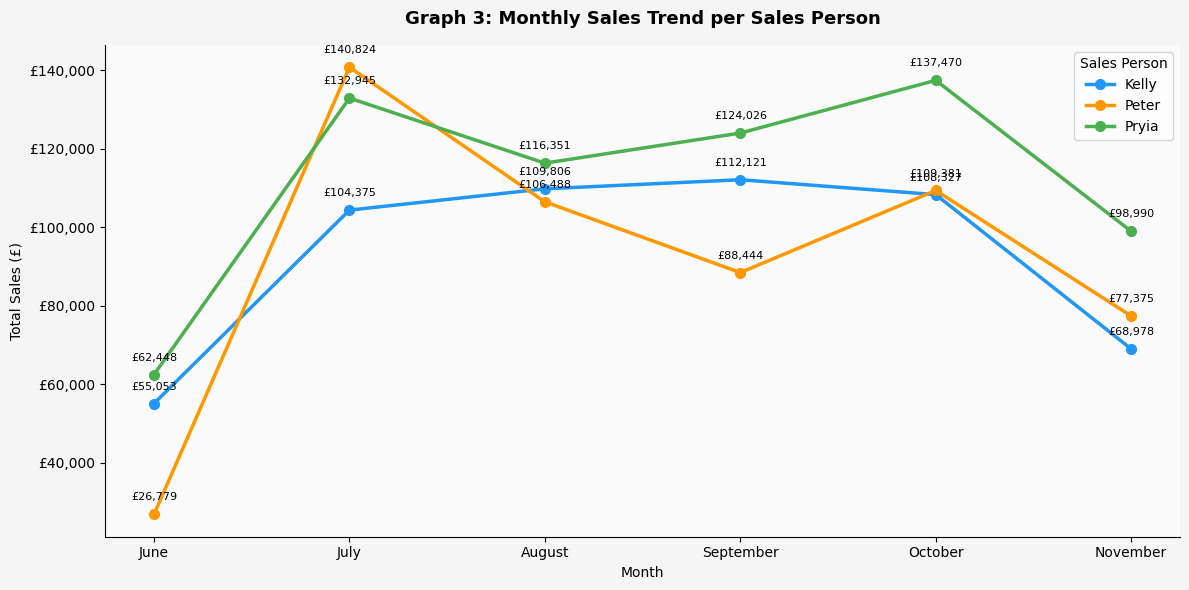

In [14]:
# Graph 3 Preparation and Creation

fig3, ax3 = plt.subplots(figsize=(12, 6))
fig3.patch.set_facecolor('#F5F5F5')

for person, grp in monthly.groupby('sales_person'):
    grp = grp.set_index('month_name').reindex(month_order)
    ax3.plot(month_order, grp['value_£'].values,
             marker='o', linewidth=2.5, markersize=7,
             label=person, color=colours[person])
    for i, val in enumerate(grp['value_£'].values):
        if not np.isnan(val):
            ax3.annotate(f'£{val:,.0f}',
                         xy=(i, val), xytext=(0, 10),
                         textcoords='offset points',
                         ha='center', fontsize=8)

ax3.set_title('Graph 3: Monthly Sales Trend per Sales Person',
              fontweight='bold', pad=15, fontsize=13)
ax3.set_ylabel('Total Sales (£)')
ax3.set_xlabel('Month')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax3.legend(title='Sales Person')
ax3.set_facecolor('#FAFAFA')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

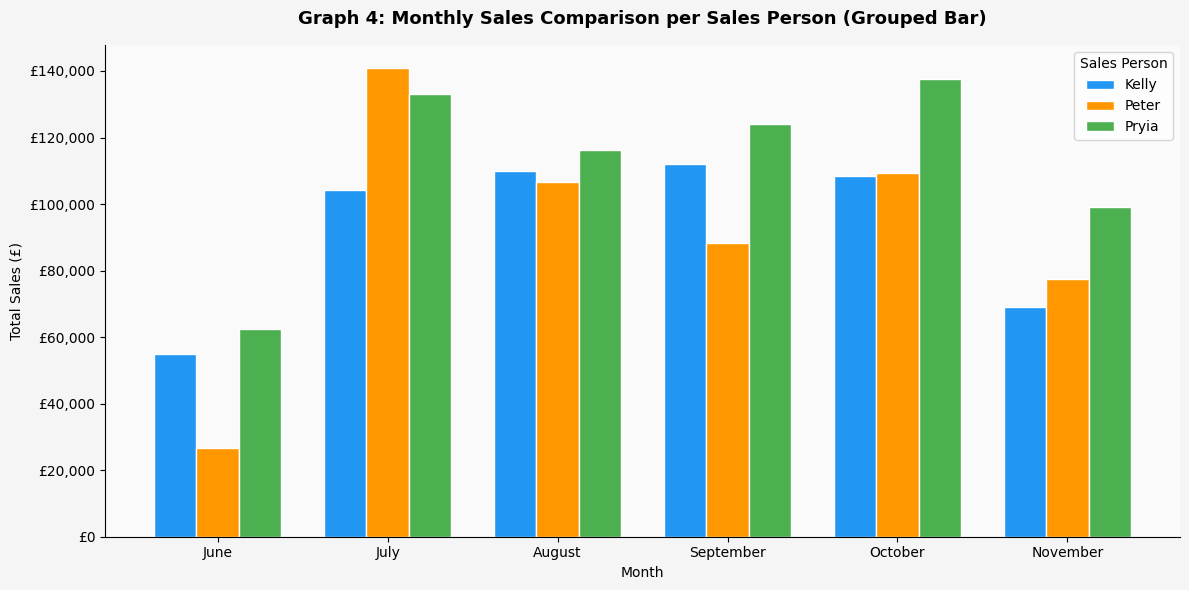

In [15]:
# Graph 4 Preparation and Creation

fig4, ax4 = plt.subplots(figsize=(12, 6))
fig4.patch.set_facecolor('#F5F5F5')

persons = ['Kelly','Peter','Pryia']
x       = np.arange(len(month_order))
width   = 0.25

for i, person in enumerate(persons):
    vals = []
    for m in month_order:
        row = monthly[(monthly['sales_person']==person) & (monthly['month_name']==m)]
        vals.append(row['value_£'].values[0] if len(row) > 0 else 0)
    ax4.bar(x + i*width, vals, width=width,
            label=person, color=colours[person], edgecolor='white')

ax4.set_title('Graph 4: Monthly Sales Comparison per Sales Person (Grouped Bar)',
              fontweight='bold', pad=15, fontsize=13)
ax4.set_ylabel('Total Sales (£)')
ax4.set_xlabel('Month')
ax4.set_xticks(x + width)
ax4.set_xticklabels(month_order)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax4.legend(title='Sales Person')
ax4.set_facecolor('#FAFAFA')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

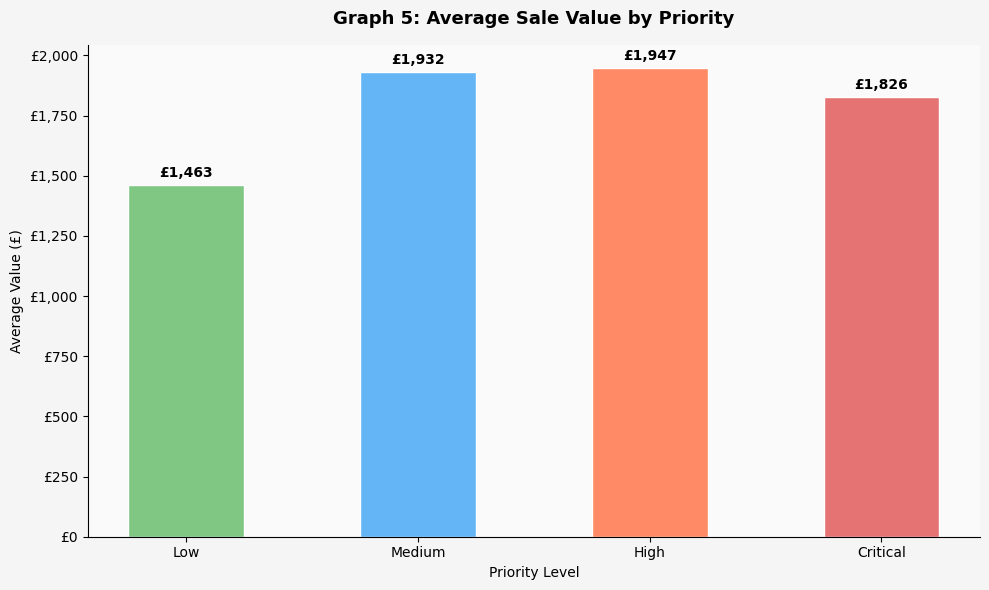

In [16]:
# Graph 5 Preparation and Creation

fig5, ax5 = plt.subplots(figsize=(10, 6))
fig5.patch.set_facecolor('#F5F5F5')

priority_avg = df.groupby('priority', observed=False)['value_£'].mean()
bars5 = ax5.bar(priority_avg.index.astype(str), priority_avg.values,
                color=priority_cols, edgecolor='white', width=0.5)
for bar, val in zip(bars5, priority_avg.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax5.set_title('Graph 5: Average Sale Value by Priority',
              fontweight='bold', pad=15, fontsize=13)
ax5.set_ylabel('Average Value (£)')
ax5.set_xlabel('Priority Level')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax5.set_facecolor('#FAFAFA')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

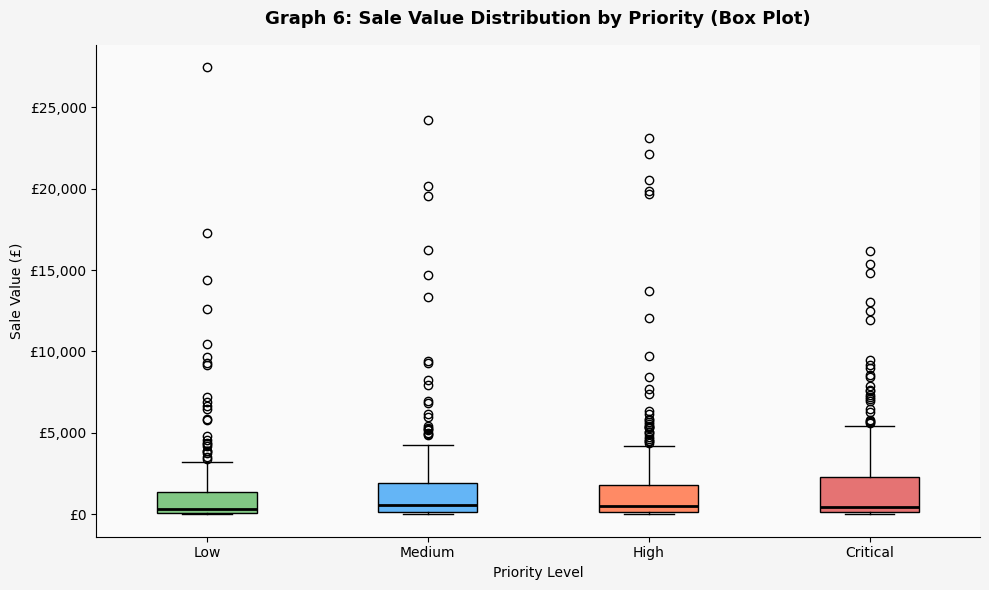

In [17]:
# Graph 6 Preparation and Creation

fig6, ax6 = plt.subplots(figsize=(10, 6))
fig6.patch.set_facecolor('#F5F5F5')

priority_levels = ['Low','Medium', 'High','Critical']
box_data = [df[df['priority']==p]['value_£'].values for p in priority_levels]
bp = ax6.boxplot(box_data, patch_artist=True, tick_labels=priority_levels,
                 medianprops=dict(color='black', linewidth=2))
for patch, colour in zip(bp['boxes'], priority_cols):
    patch.set_facecolor(colour)

ax6.set_title('Graph 6: Sale Value Distribution by Priority (Box Plot)',
              fontweight='bold', pad=15, fontsize=13)
ax6.set_ylabel('Sale Value (£)')
ax6.set_xlabel('Priority Level')
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax6.set_facecolor('#FAFAFA')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

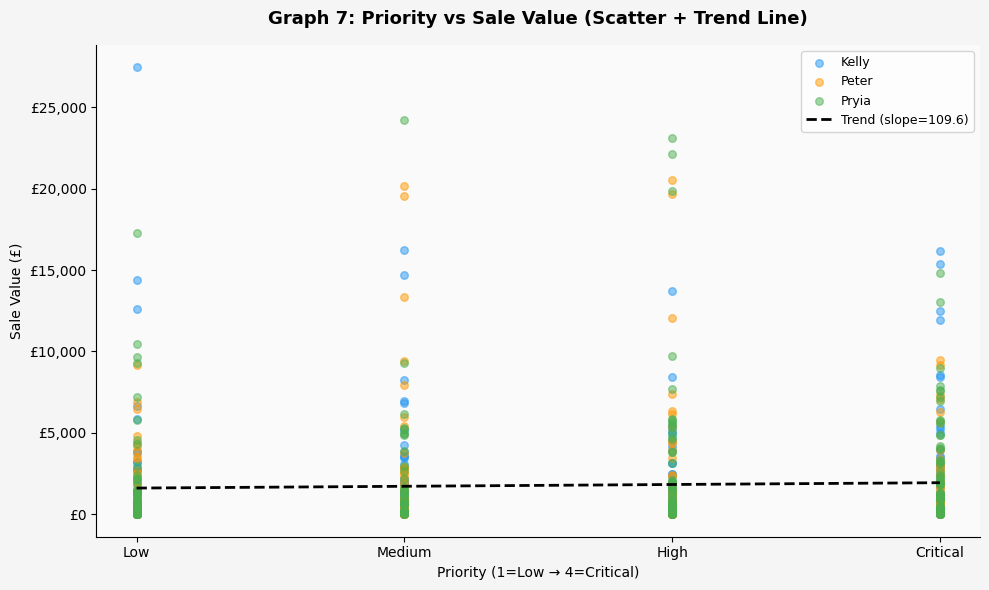

In [18]:
# Graph 7 Preparation and Creation

fig7, ax7 = plt.subplots(figsize=(10, 6))
fig7.patch.set_facecolor('#F5F5F5')

for person, grp in df.groupby('sales_person'):
    ax7.scatter(grp['priority_numeric'], grp['value_£'],
                label=person, alpha=0.5, s=30, color=colours[person])

# Filter out NaN values before performing polyfit
df_filtered = df.dropna(subset=['priority_numeric', 'value_£'])
m, b = np.polyfit(df_filtered['priority_numeric'], df_filtered['value_£'], 1)
x_line = np.linspace(1, 4, 100)
ax7.plot(x_line, m*x_line + b, color='black', linewidth=2,
         linestyle='--', label=f'Trend (slope={m:.1f})')

ax7.set_title('Graph 7: Priority vs Sale Value (Scatter + Trend Line)',
              fontweight='bold', pad=15, fontsize=13)
ax7.set_xlabel('Priority (1=Low → 4=Critical)') # Updated label
ax7.set_ylabel('Sale Value (£)')
ax7.set_xticks([1,2,3,4])
ax7.set_xticklabels(['Low','Medium','High','Critical'])
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax7.legend(fontsize=9)
ax7.set_facecolor('#FAFAFA')
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1079/1158663310.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_person = df.groupby('sales_person').apply(


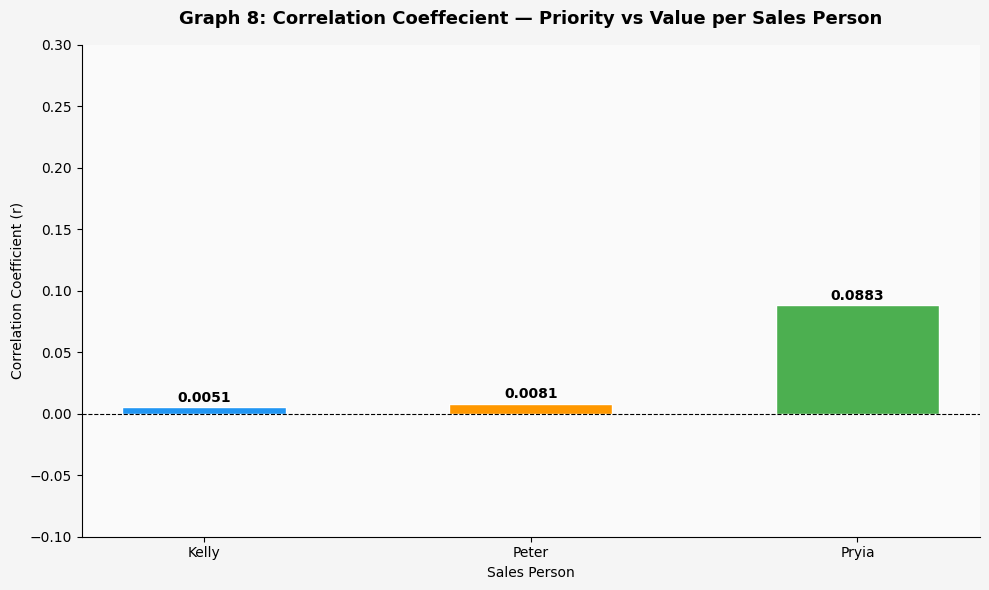

In [19]:
# Graph 8 Preparation and Creation

fig8, ax8 = plt.subplots(figsize=(10, 6))
fig8.patch.set_facecolor('#F5F5F5')

corr_by_person = df.groupby('sales_person').apply(
    lambda g: g['priority_numeric'].corr(g['value_£'])
).reset_index()
corr_by_person.columns = ['Sales Person', 'Correlation']
bar_cols = [colours[p] for p in corr_by_person['Sales Person']]

bars8 = ax8.bar(corr_by_person['Sales Person'], corr_by_person['Correlation'],
                color=bar_cols, edgecolor='white', width=0.5)
for bar, val in zip(bars8, corr_by_person['Correlation']):
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax8.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax8.set_title('Graph 8: Correlation Coeffecient — Priority vs Value per Sales Person',
              fontweight='bold', pad=15, fontsize=13)
ax8.set_ylabel('Correlation Coefficient (r)')
ax8.set_xlabel('Sales Person')
ax8.set_ylim(-0.1, 0.3)
ax8.set_facecolor('#FAFAFA')
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1079/1802769586.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spearman_corr_by_person = df.groupby('sales_person').apply(


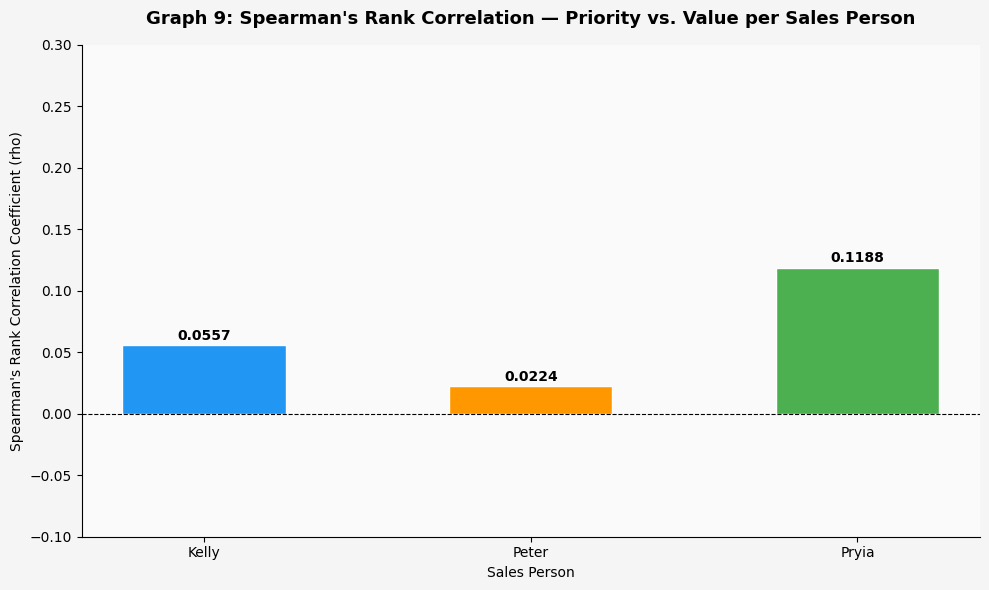

In [20]:
# Graph 9 Preparation and Creation of Spearman's Rank Correlation

fig9, ax9 = plt.subplots(figsize=(10, 6))
fig9.patch.set_facecolor('#F5F5F5')

spearman_corr_by_person = df.groupby('sales_person').apply(
    lambda g: g['priority_numeric'].corr(g['value_£'], method='spearman')
).reset_index()
spearman_corr_by_person.columns = ['Sales Person', 'Spearman_Correlation']
bar_cols_spearman = [colours[p] for p in spearman_corr_by_person['Sales Person']]

bars9 = ax9.bar(spearman_corr_by_person['Sales Person'], spearman_corr_by_person['Spearman_Correlation'],
                color=bar_cols_spearman, edgecolor='white', width=0.5)
for bar, val in zip(bars9, spearman_corr_by_person['Spearman_Correlation']):
    ax9.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax9.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax9.set_title('Graph 9: Spearman\'s Rank Correlation — Priority vs. Value per Sales Person',
              fontweight='bold', pad=15, fontsize=13)
ax9.set_ylabel('Spearman\'s Rank Correlation Coefficient (rho)')
ax9.set_xlabel('Sales Person')
ax9.set_ylim(-0.1, 0.3) # Keep consistent y-limit for comparison with Pearson
ax9.set_facecolor('#FAFAFA')
ax9.spines['top'].set_visible(False)
ax9.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()